In [1]:
# Performance config
import os

CPU_THREADS = min(32, os.cpu_count() or 32)
os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(CPU_THREADS)
os.environ["NUMEXPR_NUM_THREADS"] = str(CPU_THREADS)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"

REQUIRE_CUDA = False  # set False for CPU-only notebooks

print(f"CPU threads set to: {CPU_THREADS}")

try:
    import torch
except Exception as e:
    torch = None
    if REQUIRE_CUDA:
        raise RuntimeError("CUDA required but torch is not available.") from e

if torch is not None:
    torch.set_num_threads(CPU_THREADS)
    torch.set_num_interop_threads(min(4, CPU_THREADS))
    if REQUIRE_CUDA and not torch.cuda.is_available():
        raise RuntimeError("CUDA required but not available.")
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        print("CUDA device:", torch.cuda.get_device_name(0))
    else:
        print("CUDA not available; running on CPU.")


CPU threads set to: 32
CUDA device: NVIDIA GeForce RTX 3090


# Kvasir-VQA x1: bias/health check

Goals:
- Quantify split sizes, sources, question/answer types.
- Check ulcerative colitis (UC) coverage and yes/no skew.
- Spot potential bias (dominant sources, answer imbalance).
Outputs saved to `1_dataset_analysis/out/`.


In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")


In [3]:
# Paths

def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root containing '0_dataset_prep'. cwd={start}")

DATA_ROOT = find_dataset_root()
META_CSV = DATA_ROOT / "0_dataset_prep" / "out" / "metadata" / "metadata_enriched.csv"
OUT_DIR = DATA_ROOT / "1_dataset_analysis" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data root:", DATA_ROOT)
print("Metadata:", META_CSV)
print("Out dir:", OUT_DIR)


Data root: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1
Metadata: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/0_dataset_prep/out/metadata/metadata_enriched.csv
Out dir: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out


In [4]:
# Load
meta = pd.read_csv(META_CSV)
print("Rows:", len(meta))
print("Columns:", list(meta.columns))
print(meta.head())


Rows: 159549
Columns: ['split', 'img_id', 'image_path', 'question', 'answer', 'question_type', 'answer_type', 'question_class', 'complexity', 'original', 'orig_height', 'orig_width']
   split                     img_id  \
0  train  clb0kvxvm90y4074yf50vf5nq   
1  train  cl8k2u1r71foz083278j63qnm   
2  train  cl8k2u1qa1ekz08324rek2qcv   
3  train  cla820gmss67b071u3h7o5k3t   
4  train  clb0kvxvf90l4074y85pi02pq   

                                     image_path  \
0  out/images/all/clb0kvxvm90y4074yf50vf5nq.jpg   
1  out/images/all/cl8k2u1r71foz083278j63qnm.jpg   
2  out/images/all/cl8k2u1qa1ekz08324rek2qcv.jpg   
3  out/images/all/cla820gmss67b071u3h7o5k3t.jpg   
4  out/images/all/clb0kvxvf90l4074y85pi02pq.jpg   

                                            question  \
0  Are there any abnormalities, polyps, or anatom...   
1  What procedure is depicted in the image and wh...   
2  Have all polyps been removed, is there any tex...   
3  Are there any surgical instruments, polyps, or..

In [5]:
# Derive simple question/answer types
import re

def classify_answer_type(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return 'unknown'
    t = text.strip().lower()
    if t in {'yes', 'no'}:
        return 'yes_no'
    if re.fullmatch(r'[0-9]+', t):
        return 'number'
    if ',' in t:
        return 'list'
    return 'open'

def classify_question_type(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return 'unknown'
    t = text.lower()
    if t.startswith(('is ', 'are ', 'does ', 'do ', 'has ', 'have ', 'can ')):
        return 'yes_no'
    if any(t.startswith(p) for p in ['how many', 'what is the number', 'count']):
        return 'counting'
    if any(k in t for k in ['what', 'which', 'identify', 'name']):
        return 'open'
    return 'other'

if 'answer' in meta:
    meta['answer_type'] = meta['answer'].apply(classify_answer_type)
if 'question' in meta:
    meta['question_type'] = meta['question'].apply(classify_question_type)

print('Derived answer_type counts:', meta.get('answer_type', pd.Series(dtype=str)).value_counts())
print('Derived question_type counts:', meta.get('question_type', pd.Series(dtype=str)).value_counts())


Derived answer_type counts: answer_type
open    95905
list    63644
Name: count, dtype: int64
Derived question_type counts: question_type
yes_no      81946
open        52462
counting    18312
other        6829
Name: count, dtype: int64


In [6]:
# Nulls and splits
print("Nulls per column:", meta.isnull().sum())
print("Splits:", meta.get("split", pd.Series(dtype=str)).value_counts())

Nulls per column: split                  0
img_id                 0
image_path             0
question               0
answer                 0
question_type          0
answer_type            0
question_class         0
complexity             0
original               0
orig_height       159549
orig_width        159549
dtype: int64
Splits: split
train    143594
test      15955
Name: count, dtype: int64


In [7]:
# Source distribution (if present)
if "source" in meta:
    print("Sources:", meta["source"].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(y="source", data=meta, order=meta["source"].value_counts().index)
    plt.title("Source counts")
    plt.tight_layout()
    fp = OUT_DIR / "source_counts.png"
    plt.savefig(fp, dpi=200)
    plt.show()
    print("Saved:", fp)


Answer types: answer_type
open    95905
list    63644
Name: count, dtype: int64


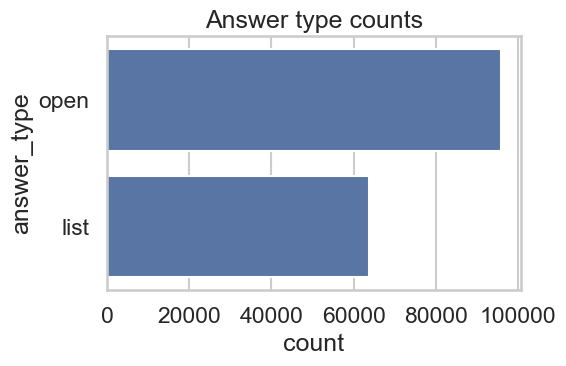

Saved: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out/answer_type_counts.png
Question types: question_type
yes_no      81946
open        52462
counting    18312
other        6829
Name: count, dtype: int64


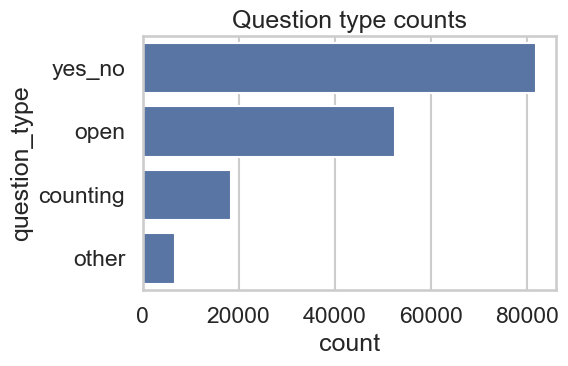

Saved: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out/question_type_counts.png


In [8]:
# Answer type / Question type
if "answer_type" in meta:
    print("Answer types:", meta["answer_type"].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(y="answer_type", data=meta, order=meta["answer_type"].value_counts().index)
    plt.title("Answer type counts")
    plt.tight_layout()
    fp = OUT_DIR / "answer_type_counts.png"
    plt.savefig(fp, dpi=200)
    plt.show()
    print("Saved:", fp)
if "question_type" in meta:
    print("Question types:", meta["question_type"].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(y="question_type", data=meta, order=meta["question_type"].value_counts().index)
    plt.title("Question type counts")
    plt.tight_layout()
    fp = OUT_DIR / "question_type_counts.png"
    plt.savefig(fp, dpi=200)
    plt.show()
    print("Saved:", fp)


In [9]:
# Yes/No skew if applicable
if "answer" in meta:
    ans_norm = (
        meta["answer"].astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r"[^a-z]", "", regex=True)
    )
    yn = meta[ans_norm.isin(["yes", "no"])].copy()
    if len(yn) > 0:
        print("Yes/No counts:", ans_norm.loc[yn.index].value_counts())


In [10]:
# UC-related coverage (simple keyword match)
if "source" in meta or "question" in meta or "answer" in meta:
    uc_mask = pd.Series(False, index=meta.index)
    for col in ["source","question","answer"]:
        if col in meta:
            uc_mask |= meta[col].astype(str).str.contains(r"\bulcerative colitis\b|\buc\b", case=False, na=False)
    uc_rows = meta[uc_mask]
    print("UC-related rows:", len(uc_rows))
    if len(uc_rows) > 0 and "answer_type" in meta:
        print("UC answer types:", uc_rows["answer_type"].value_counts())


UC-related rows: 4349
UC answer types: answer_type
list    2544
open    1805
Name: count, dtype: int64


        question_len     answer_len
count  159549.000000  159549.000000
mean       79.815066      67.482629
std        29.719677      36.805278
min        26.000000      13.000000
25%        52.000000      36.000000
50%        79.000000      62.000000
75%       105.000000      89.000000
max       286.000000     331.000000


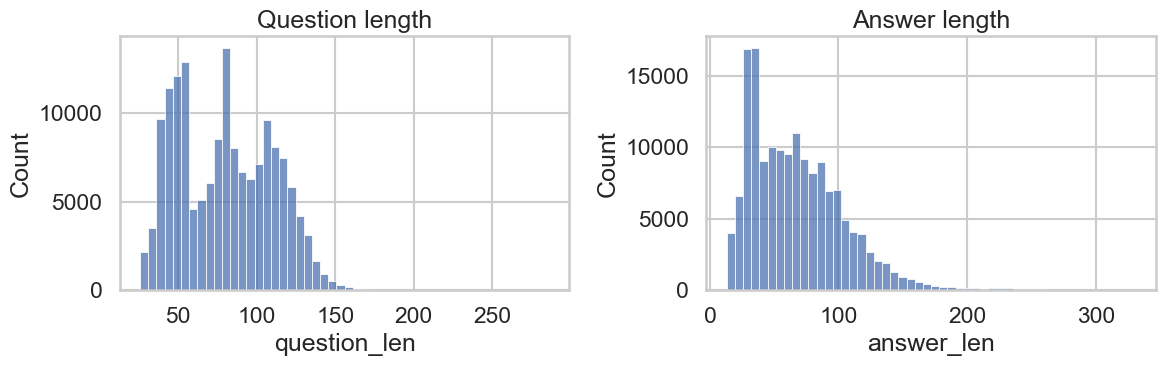

Saved: /mnt/hf/thesis/rag-vqa-medical/Prototyping_reformat/DatasetAnalysis/Kvasir_VQA_x1/1_dataset_analysis/out/length_hists.png


In [11]:
# Text length stats
meta["question_len"] = meta["question"].fillna("").astype(str).str.len()
meta["answer_len"] = meta["answer"].fillna("").astype(str).str.len()
print(meta[["question_len", "answer_len"]].describe())

fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(meta["question_len"], bins=50, ax=axes[0])
axes[0].set_title("Question length")
sns.histplot(meta["answer_len"], bins=50, ax=axes[1])
axes[1].set_title("Answer length")
plt.tight_layout()
fp = OUT_DIR / "length_hists.png"
plt.savefig(fp, dpi=200)
plt.show()
print("Saved:", fp)


In [12]:
# Top answers and top question prefixes
print("Top answers:", meta["answer"].value_counts().head(10))
print("Top question prefixes:", meta["question"].astype(str).str[:30].value_counts().head(10))


Top answers: answer
evidence of colonoscopy procedure        1903
No residual polyp tissue identified      1149
No instruments observed                   999
No anatomical landmarks identified        904
No evidence of box artifacts observed     875
No surgical instruments observed          812
one surgical instrument present           807
one abnormal finding present              782
No polyps observed                        781
No surgical instruments identified        763
Name: count, dtype: int64
Top question prefixes: question
Are there any green or black b    7169
What procedure is depicted in     7160
Are there any instruments visi    6035
Are there any abnormalities in    4220
Are there any anatomical landm    3935
Have all polyps been removed,     3385
Are there any abnormalities vi    3016
Is there a green/black box art    2846
In which regions of the image     2715
What type of polyp is present     2676
Name: count, dtype: int64
